# VisionBlurMasker — Gaussian Blur Occlusion

Compares two occlusion strategies on the same CLIP ViT-B/32 model:
1. **CrossModalMeanMasker** — multiplicative zero-out (baseline)
2. **VisionBlurMasker** — Gaussian blur in masked regions (B3)

**How blur masking works:**
- Each masked region is replaced with a Gaussian-weighted average of surrounding pixels
- Blending: `output = original * mask + blurred * (1 - mask)`
- Controlled by `VisionBlurParams(sigma=...)` — larger sigma = softer occlusion


In [ ]:
from pathlib import Path
import sys, time

import numpy as np
import torch
torch.set_float32_matmul_precision("high")

from PIL import Image
from transformers import CLIPModel, CLIPProcessor
import matplotlib.pyplot as plt
import shapiq

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.fixlip import FIxLIP
from src import utils
from shapiq.imputer.vision import VisionImputerFactory, SegmenterConfig
from shapiq.imputer.vision import MaskerConfig, VisionBlurParams
from src.plot import plot_image_and_text_together
from shapiq.imputer.vision import VisionLanguageGame

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cuda


## Load model and data


In [2]:
MODEL_ID = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(MODEL_ID).to(DEVICE).eval()
processor = CLIPProcessor.from_pretrained(MODEL_ID)

input_text = "black dog next to a yellow hydrant"
input_image = Image.open("assets/dog_and_hydrant.png").convert("RGB")

print(f"Model: {MODEL_ID}")
print(f"Image size: {input_image.size}")
print(f"Text: '{input_text}'")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model: openai/clip-vit-base-patch32
Image size: (511, 511)
Text: 'black dog next to a yellow hydrant'


## Build two imputers for comparison

- **mean**: `CrossModalMeanMasker` — baseline (image zero-out + text attention swap)
- **blur**: `CrossModalBlurMasker` — Gaussian-blur image + text attention swap

Both are **cross-modal composites** so the comparison is fair: they differ
only in the image-side occlusion (zero-out vs Gaussian blur). The text side
(attention-mask swap) is identical.

In [3]:
factory = VisionImputerFactory()

# Baseline: cross-modal mean masking (image zero-out + text attention swap)
imputer_mean = factory.build(model, processor, input_image, input_text)

# Blur masking: cross-modal composite — Gaussian-blur image + text attention swap.
# NOTE: use "crossmodal_blur" (not "vision_blur") for cross-modal games.
# "vision_blur" is image-only and would leave text un-masked, producing
# meaningless text attributions.
masker_cfg = MaskerConfig(
    strategy="crossmodal_blur",
    vision_blur=VisionBlurParams(sigma=3.0),
)
imputer_blur = factory.build(
    model, processor, input_image, input_text,
    masker_config=masker_cfg,
)

print(f"Masker (mean): {type(imputer_mean.masker).__name__}")
print(f"Masker (blur): {type(imputer_blur.masker).__name__}")
print(f"Sigma: {masker_cfg.vision_blur.sigma}")

Masker (mean): CrossModalMeanMasker
Masker (blur): CrossModalBlurMasker
Sigma: 3.0


## Create game wrappers


In [4]:
BATCH_SIZE = 64

game_mean = VisionLanguageGame(imputer_mean, batch_size=BATCH_SIZE)
game_blur = VisionLanguageGame(imputer_blur, batch_size=BATCH_SIZE)

print(f"Game (mean): n_img={game_mean.n_players_image}, n_txt={game_mean.n_players_text}")
print(f"Game (blur): n_img={game_blur.n_players_image}, n_txt={game_blur.n_players_text}")
print(f"Normalization - mean: empty={game_mean.empty_value:.2f}, full={game_mean.full_value:.2f}")
print(f"Normalization - blur: empty={game_blur.empty_value:.2f}, full={game_blur.full_value:.2f}")


Game (mean): n_img=49, n_txt=8
Game (blur): n_img=49, n_txt=8
Normalization - mean: empty=22.87, full=33.95
Normalization - blur: empty=21.52, full=33.95


## Define approximator


In [5]:
fixlip = FIxLIP(
    n_players_image=game_mean.n_players_image,
    n_players_text=game_mean.n_players_text,
    max_order=2,
    p=0.5,
    mode="banzhaf",
    random_state=0,
)


## Compute explanations for both maskers


In [6]:
BUDGET = 2**18
utils.set_seed(0)

print("Computing explanation (mean) ...")
t0 = time.perf_counter()
iv_mean = fixlip.approximate_crossmodal(game_mean, budget=BUDGET)
t_mean = time.perf_counter() - t0
print(f"  done in {t_mean:.1f}s")

print("Computing explanation (blur) ...")
t0 = time.perf_counter()
iv_blur = fixlip.approximate_crossmodal(game_blur, budget=BUDGET)
t_blur = time.perf_counter() - t0
print(f"  done in {t_blur:.1f}s")

print(f"\nMean interaction values:\n{iv_mean}")
print(f"\nBlur interaction values:\n{iv_blur}")


Computing explanation (mean) ...
  done in 18.1s
Computing explanation (blur) ...
  done in 31.4s

Mean interaction values:
InteractionValues(
    index=FBII, max_order=2, min_order=0, estimated=True, estimation_budget=262080,
    n_players=57, baseline_value=0.0529446586004031,
    Top 10 interactions:
        (54,): 2.3378442293637525
        (33, 55): 1.7146165731863416
        (55, 56): 1.347700676381812
        (28, 50): 1.3138722570885673
        (29, 50): 1.3002614538435981
        (36, 50): 1.2254677722450527
        (52,): -2.274533055962173
        (56,): -2.310626816561853
        (50,): -4.704456834001086
        (55,): -6.744579995924447
)

Blur interaction values:
InteractionValues(
    index=FBII, max_order=2, min_order=0, estimated=True, estimation_budget=262080,
    n_players=57, baseline_value=3.5584696204717527,
    Top 10 interactions:
        (55, 56): 7.109878378540681
        (): 3.5584696204717527
        (54,): 2.766755297503359
        (51, 52): 1.937289673182

## Compare first-order attributions


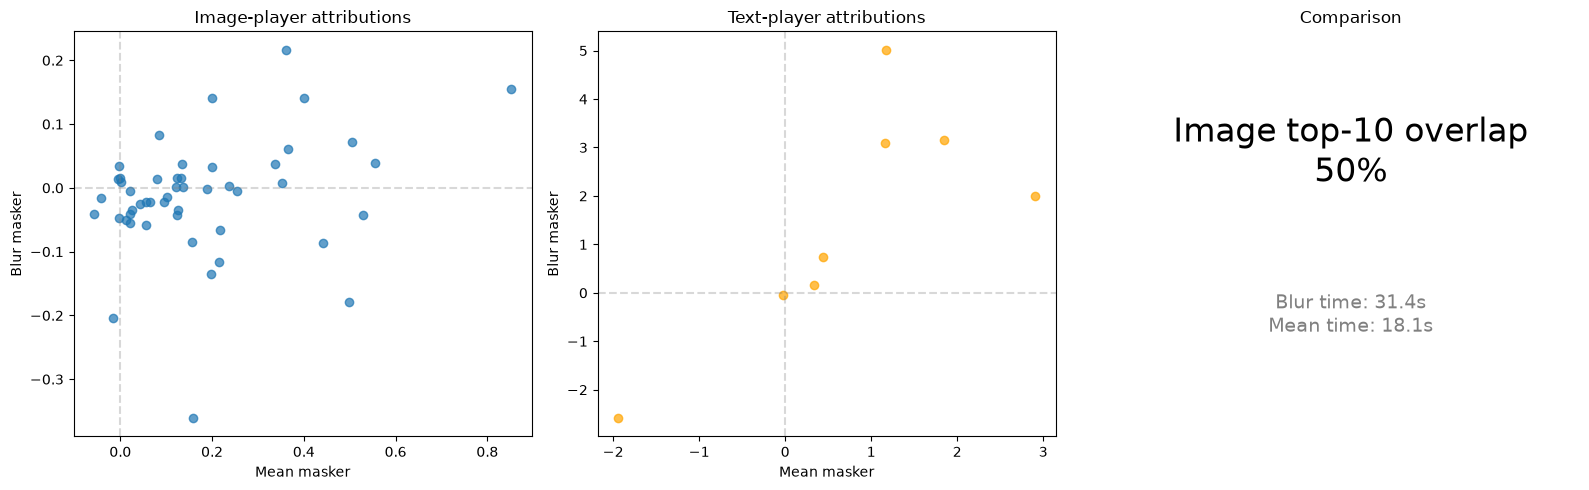

In [7]:
fo_mean = utils.convert_iv_to_first_order(iv_mean).get_n_order(1).values
fo_blur = utils.convert_iv_to_first_order(iv_blur).get_n_order(1).values

# Image-only comparison
img_mean = fo_mean[:game_mean.n_players_image]
img_blur = fo_blur[:game_mean.n_players_image]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(img_mean, img_blur, alpha=0.7)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[0].set_xlabel("Mean masker")
axes[0].set_ylabel("Blur masker")
axes[0].set_title("Image-player attributions")

# Text-only comparison
txt_mean = fo_mean[game_mean.n_players_image:]
txt_blur = fo_blur[game_mean.n_players_image:]

axes[1].scatter(txt_mean, txt_blur, alpha=0.7, color='orange')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[1].set_xlabel("Mean masker")
axes[1].set_ylabel("Blur masker")
axes[1].set_title("Text-player attributions")

# Top-k rank overlap
k = 10
top_img_mean = set(np.argsort(np.abs(img_mean))[-k:])
top_img_blur = set(np.argsort(np.abs(img_blur))[-k:])
overlap = len(top_img_mean & top_img_blur) / k

axes[2].axis("off")
axes[2].text(0.5, 0.7, f"Image top-{k} overlap\n{overlap*100:.0f}%",
             ha="center", va="center", fontsize=24, transform=axes[2].transAxes)
axes[2].text(0.5, 0.3, f"Blur time: {t_blur:.1f}s\nMean time: {t_mean:.1f}s",
             ha="center", va="center", fontsize=14, transform=axes[2].transAxes,
             color='gray')
axes[2].set_title("Comparison")

plt.tight_layout()
plt.show()


## Max-drop leave-one-patch-out check

For each image patch, remove only that patch while keeping all text tokens active. The drop is `full_value - masked_value`; larger positive values mean the model score depends more on that patch.


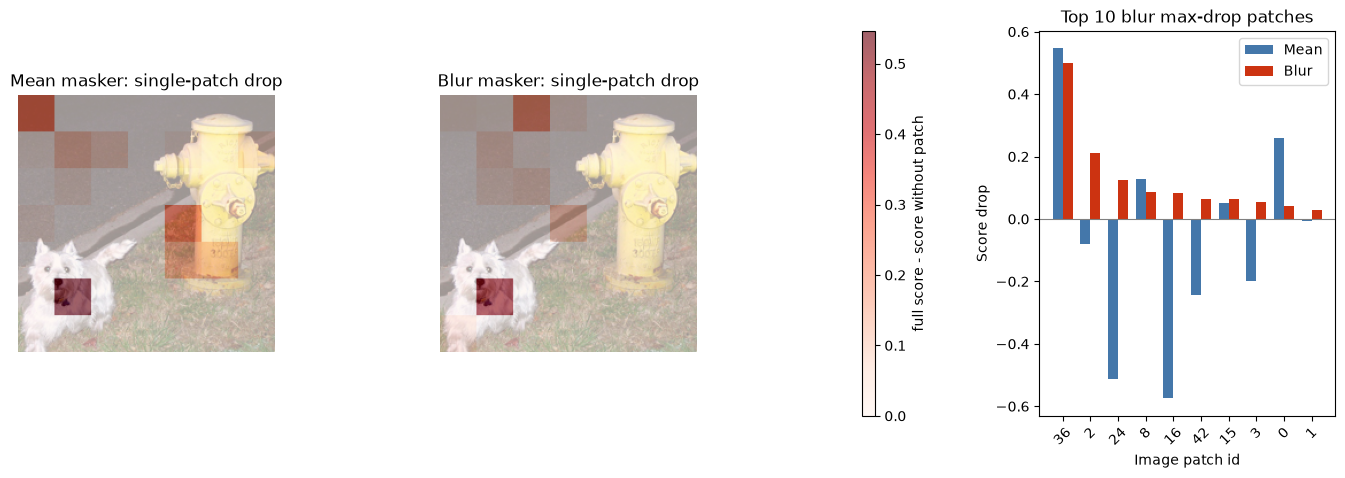

Mean max drop: patch 36, drop=0.5466
Blur max drop: patch 36, drop=0.4997


In [8]:
def image_patch_max_drop(game, batch_size=BATCH_SIZE):
    coalitions = np.ones((game.n_players_image, game.n_players), dtype=bool)
    for player in range(game.n_players_image):
        coalitions[player, player] = False
    values = game.value_function(coalitions, batch_size=batch_size)
    return game.full_value - values

mean_drop = image_patch_max_drop(game_mean)
blur_drop = image_patch_max_drop(game_blur)

img_denorm_drop = utils.denormalize(
    game_mean.inputs["pixel_values"].squeeze(0),
    game_mean.processor.image_processor.image_mean,
    game_mean.processor.image_processor.image_std,
).permute(1, 2, 0).numpy()

grid_size = int(np.sqrt(game_mean.n_players_image))
if grid_size * grid_size != game_mean.n_players_image:
    raise ValueError("Max-drop visualization currently expects a square patch grid.")

patch_h = img_denorm_drop.shape[0] // grid_size
patch_w = img_denorm_drop.shape[1] // grid_size
mean_drop_map = np.repeat(np.repeat(mean_drop.reshape(grid_size, grid_size), patch_h, axis=0), patch_w, axis=1)
blur_drop_map = np.repeat(np.repeat(blur_drop.reshape(grid_size, grid_size), patch_h, axis=0), patch_w, axis=1)

vmax = max(float(np.nanmax(mean_drop)), float(np.nanmax(blur_drop)), 1e-6)
fig = plt.figure(figsize=(17, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.05, 1.15], wspace=0.8)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 3])]
cax = fig.add_subplot(gs[0, 2])

for ax, drop_map, title in [
    (axes[0], mean_drop_map, "Mean masker: single-patch drop"),
    (axes[1], blur_drop_map, "Blur masker: single-patch drop"),
]:
    ax.imshow(img_denorm_drop)
    overlay = ax.imshow(drop_map, cmap="Reds", alpha=0.62, vmin=0.0, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(overlay, cax=cax, label="full score - score without patch")

top_k_drop = 10
top_idx = np.argsort(blur_drop)[-top_k_drop:][::-1]
x = np.arange(top_k_drop)
axes[2].bar(x - 0.18, mean_drop[top_idx], width=0.36, label="Mean", color="#4477aa")
axes[2].bar(x + 0.18, blur_drop[top_idx], width=0.36, label="Blur", color="#cc3311")
axes[2].axhline(0.0, color="gray", linewidth=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels([str(i) for i in top_idx], rotation=45)
axes[2].set_title(f"Top {top_k_drop} blur max-drop patches")
axes[2].set_xlabel("Image patch id")
axes[2].set_ylabel("Score drop")
axes[2].legend()

# GridSpec controls spacing; avoid tight_layout pulling panels back together.
plt.show()

print(f"Mean max drop: patch {int(np.argmax(mean_drop))}, drop={float(np.max(mean_drop)):.4f}")
print(f"Blur max drop: patch {int(np.argmax(blur_drop))}, drop={float(np.max(blur_drop)):.4f}")


## Visualize: Mean masker (baseline)


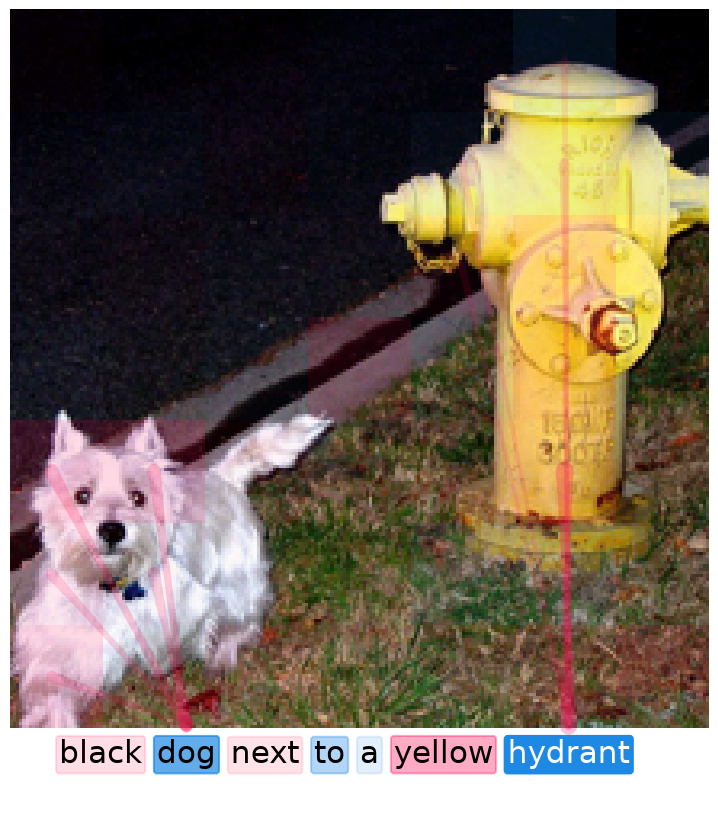

In [ ]:
text_tokens = input_text.split()
if len(text_tokens) < game_mean.n_players_text:
    text_tokens = text_tokens + [""] * (game_mean.n_players_text - len(text_tokens))

img_denorm = utils.denormalize(
    game_mean.inputs["pixel_values"].squeeze(0),
    game_mean.processor.image_processor.image_mean,
    game_mean.processor.image_processor.image_std,
).permute(1, 2, 0).numpy()

plot_image_and_text_together(
    img=img_denorm,
    text=text_tokens,
    image_players=list(range(game_mean.n_players_image)),
    iv=iv_mean,
    segmenter=imputer_mean.segmenter,
    plot_heatmap=True,
    plot_interactions=True,
    top_k=14,
    figsize=(7, 8),
    fontsize=22,
)


## Visualize: Blur masker (Gaussian, sigma=3.0)


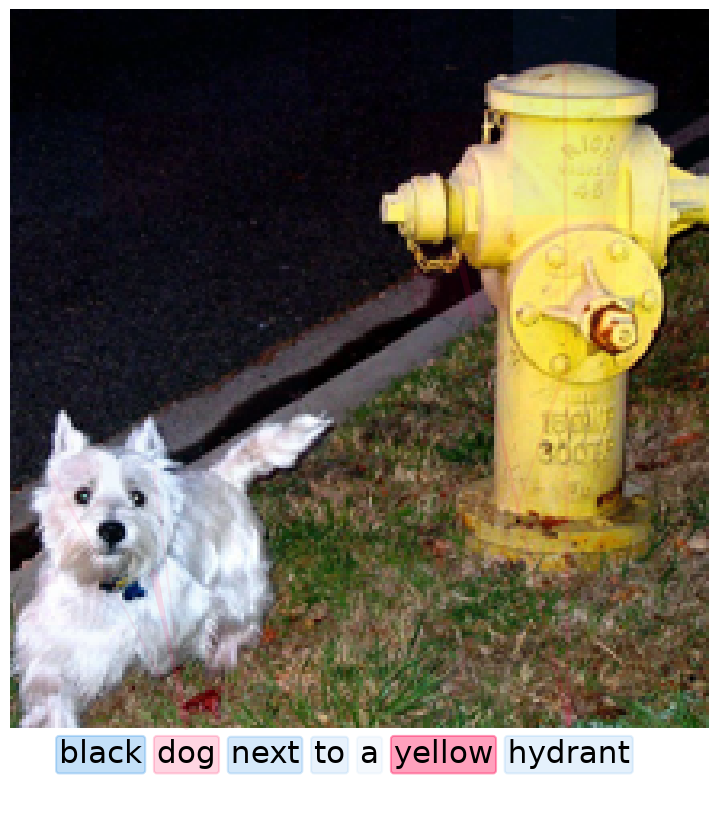

In [ ]:
plot_image_and_text_together(
    img=img_denorm,
    text=text_tokens,
    image_players=list(range(game_blur.n_players_image)),
    iv=iv_blur,
    segmenter=imputer_blur.segmenter,
    plot_heatmap=True,
    plot_interactions=True,
    top_k=14,
    figsize=(7, 8),
    fontsize=22
)